## **Health Insurance Cross Sell Prediction**

### Executive Summary

This project analyzes 381,109 health insurance customers to identify the factors associated with customer response in purchasing vehicle insurance. The analysis explores demographic, vehicle, insurance, and customer-related factors such as age, vehicle damage, previous insurance status, annual premium, and sales channel.

The goal is to identify customer characteristics and combinations associated with higher response rates and use these findings to inform customer segmentation and future predictive modeling.

Install and Import Modules into my workspace 

In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Importing and cleaning the data

Load my dataset into my workspace using "pd.read_csv" to view the dataset

For the purpose of this dataset, which is to predict customers who are likely to purchase vehicle insurance, only "train.csv" contains the "Response" variable indicating whether a customer showed interest in vehicle insurance. Therefore, "train.csv" will be used as the primary dataset for our analysis and EDA.


In [2]:
train = pd.read_csv('train.csv')
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 40.5 MB


In [3]:
train

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [4]:
#Calculating the percentage of both response as a univariate analysis and rounding it to 2 decimal places. The result is reset to a new DataFrame with a column name 'Percentage'.
pct_response = (train['Response'].value_counts(normalize = True) *100).round(2).reset_index(name = 'Percentage')
pct_response

,Response,Percentage
0,0,87.74
1,1,12.26


Across the dataset, 87.74% of customers responded (0) "No" to the vehicle insurance offer, while only 12.26% responded (1) "Yes". This indicates a strong class imbalance, with the majority of customers showing no interest in the insurance offer.

In [5]:
train['Response'].value_counts()


Response
0    334399
1     46710
Name: count, dtype: int64

In [6]:
#Checking for missing values in the train dataset. The sum of missing values for each column is displayed.
train.isnull().sum() 

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [7]:
#Checking for duplicate rows in the train dataset. The sum of duplicate rows is displayed.
train.duplicated().sum() 

np.int64(0)

In [8]:
#Displaying summary statistics for the numerical columns in the train dataset.
train.describe(include='all')

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109,381109.000000,381109.000000,381109.000000,381109.000000,381109,381109,381109.000000,381109.000000,381109.000000,381109.000000
unique,NaN,2,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,1-2 Year,Yes,NaN,NaN,NaN,NaN
freq,NaN,206089,NaN,NaN,NaN,NaN,200316,192413,NaN,NaN,NaN,NaN
mean,190555.000000,NaN,38.822584,0.997869,26.388807,0.458210,NaN,NaN,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,NaN,15.511611,0.046110,13.229888,0.498251,NaN,NaN,17213.155057,54.203995,83.671304,0.327936
min,1.000000,NaN,20.000000,0.000000,0.000000,0.000000,NaN,NaN,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,NaN,25.000000,1.000000,15.000000,0.000000,NaN,NaN,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,NaN,36.000000,1.000000,28.000000,0.000000,NaN,NaN,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,NaN,49.000000,1.000000,35.000000,1.000000,NaN,NaN,39400.000000,152.000000,227.000000,0.000000


### Data Integrity Check

For both groups, every column returned the same count as the group's total row count (46,710 for Yes, 334,399 for No) confirming that no column has missing values within either group. This is consistent with the earlier "train.isnull().sum()" check, which showed zero nulls and "train.duplicated().sum()" shows no duplicate across the entire dataset.

## Univariate Analysis

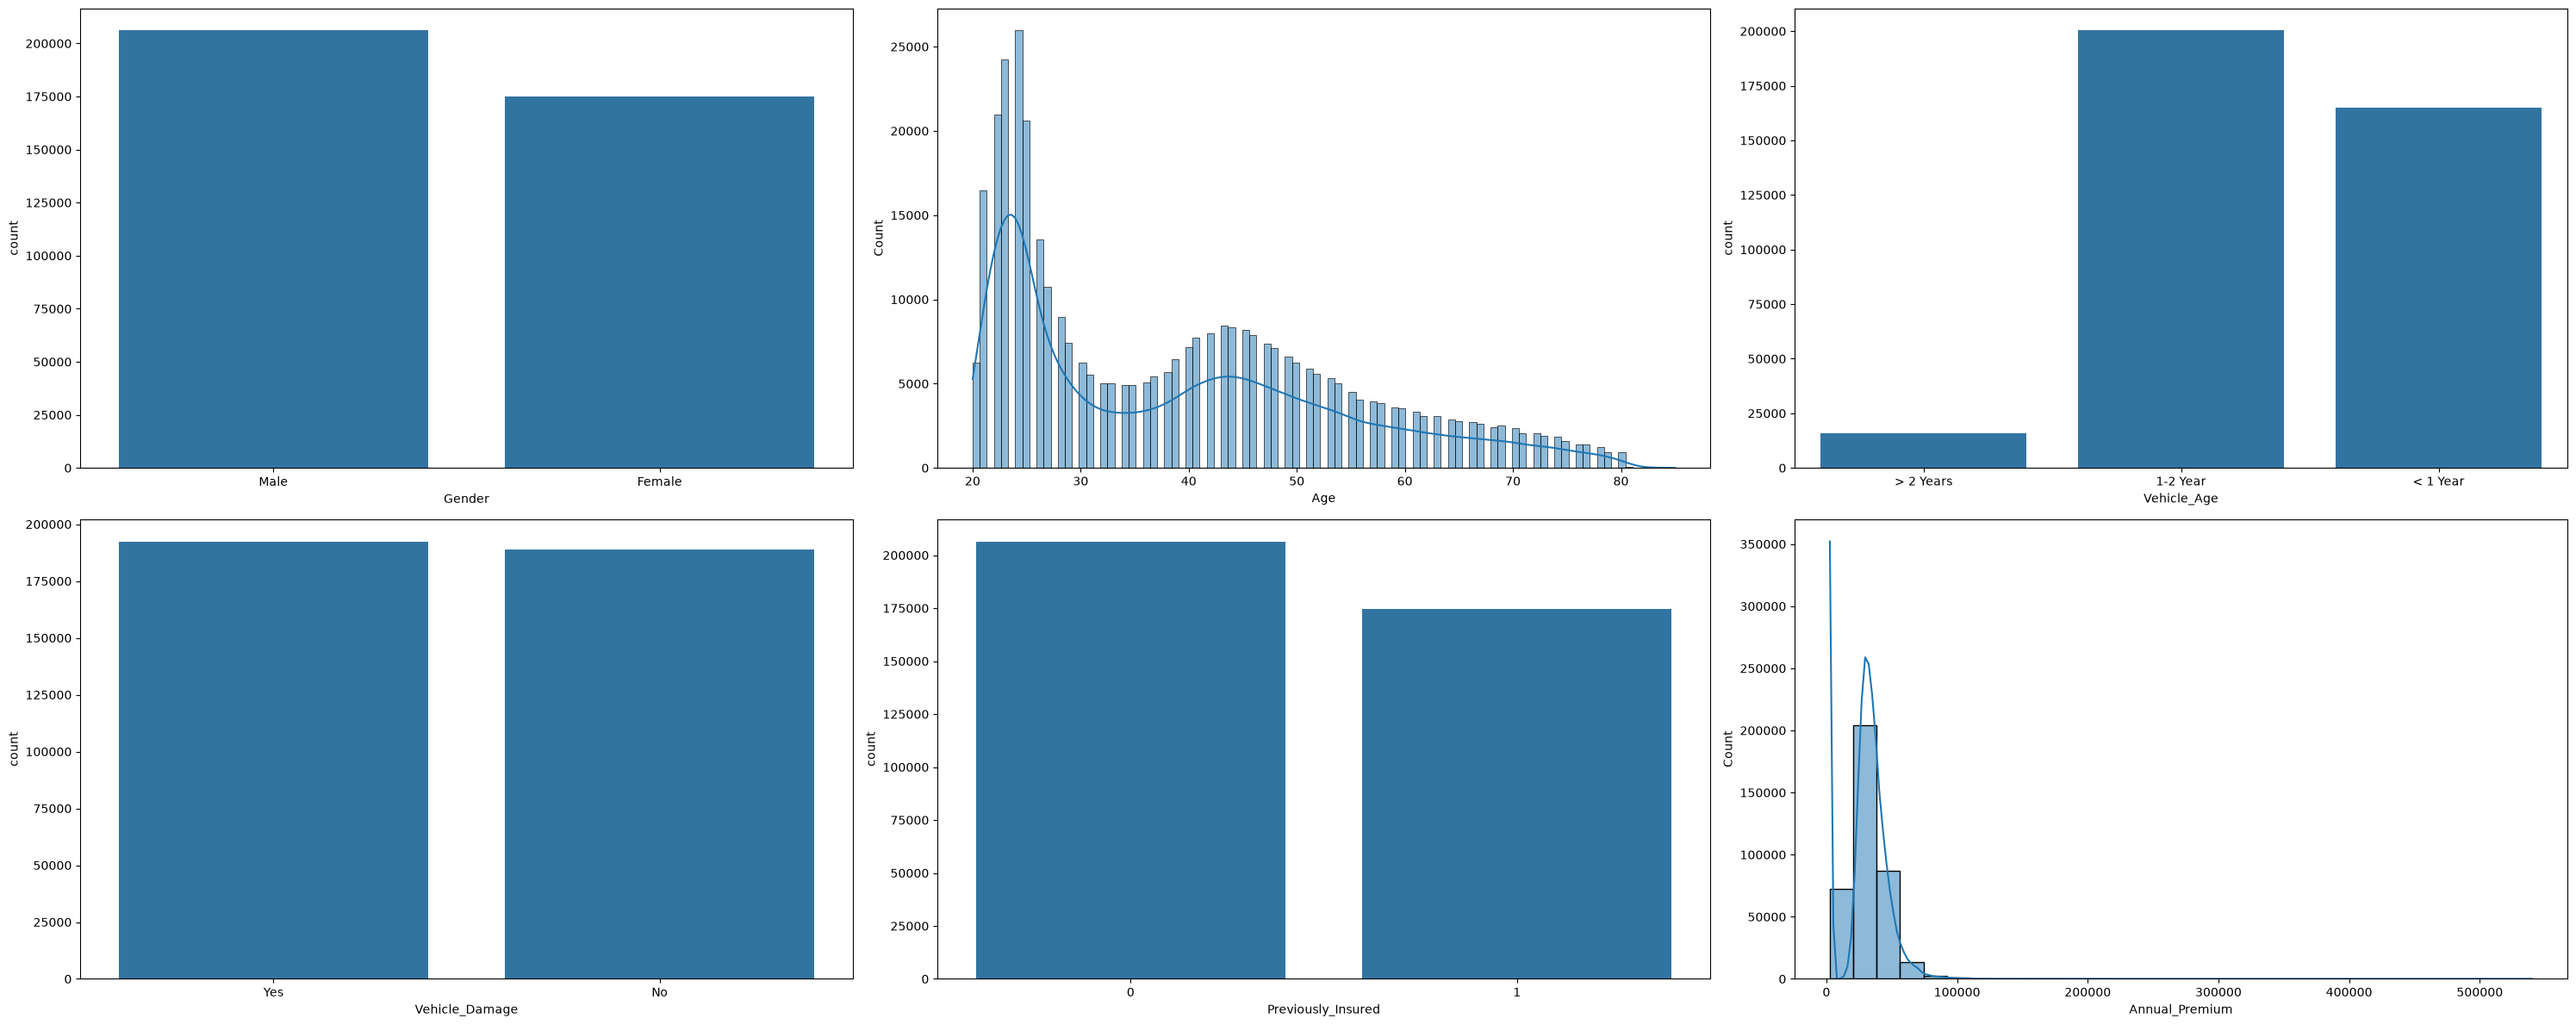

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(30, 12))

sns.countplot(data=train, x='Gender', ax=axes[0, 0])
sns.histplot(data=train, x='Age', kde=True, ax=axes[0, 1])
sns.countplot(data=train, x='Vehicle_Age', ax=axes[0, 2])
sns.countplot(data=train, x='Vehicle_Damage', ax=axes[1, 0])
sns.countplot(data=train, x='Previously_Insured', ax=axes[1, 1])
sns.histplot(data=train, x='Annual_Premium', kde=True, bins=30, ax=axes[1, 2])

plt.tight_layout()
plt.show()

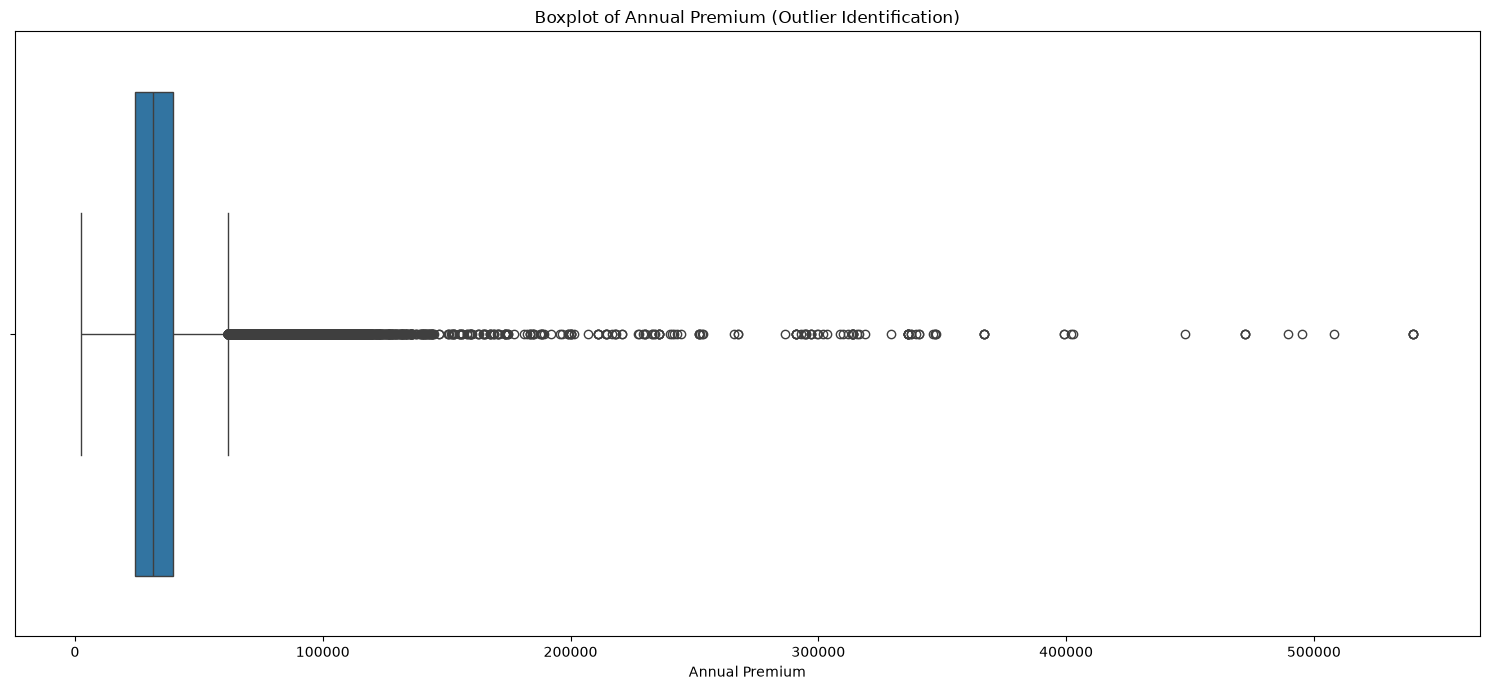

In [10]:
plt.figure(figsize=(15, 7))

#Creating a boxplot to visualize the distribution of the 'Annual_Premium' column in the train dataset.
sns.boxplot(data=train, x='Annual_Premium')
plt.title('Boxplot of Annual Premium (Outlier Identification)')
plt.xlabel('Annual Premium')
plt.tight_layout()
plt.show()

The Annual Premium distribution is strongly right-skewed, with most customers concentrated within the lower premium range. The boxplot also shows numerous high-value observations beyond the upper whisker. These values were retained because an outlier is not necessarily an invalid observation and may represent legitimate customer premiums.

## Bivariate Analysis

This section examines the relationship between each variable and the target variable "Response", to identify which factors are associated with higher or lower likelihood of a customer expressing interest in vehicle insurance.

In [11]:
gender_analysis = pd.crosstab(train['Gender'], train['Response'], margins=True)
gender_analysis.columns = ['No', 'Yes', 'Total']
gender_analysis['Response_Rate (%)'] = ((gender_analysis['Yes'] / gender_analysis['Total']) * 100).round(2)
gender_analysis

,No,Yes,Total,Response_Rate (%)
Gender,,,,
Female,156835,18185,175020,10.39
Male,177564,28525,206089,13.84
All,334399,46710,381109,12.26


The dataset skews slightly male, with 206,089 male customers compared to 175,020 female customers. Independently, males also show a slightly higher response rate 13.84% compared to 10.39% for females though this gap is modest relative to some of the other variables analyzed further on.

In [12]:
damage_analysis = pd.crosstab(train['Vehicle_Damage'], train['Response'], margins=True)
damage_analysis.columns = ['No', 'Yes', 'Total']
damage_analysis['Response_Rate (%)'] = ((damage_analysis['Yes'] / damage_analysis['Total']) * 100).round(2)
damage_analysis

,No,Yes,Total,Response_Rate (%)
Vehicle_Damage,,,,
No,187714,982,188696,0.52
Yes,146685,45728,192413,23.77
All,334399,46710,381109,12.26


Vehicle damage history is roughly evenly split across the dataset 192,413 customers have previously damaged their vehicle, compared to 188,696 who haven't. However, the two groups respond very differently: 23.77% of customers with a damage history express interest in vehicle insurance, compared to just 0.52% of those without. This shows that customers with a history of vehicle damage are far more likely to be interested in vehicle insurance than those without.

In [13]:
driving_license_analysis = pd.crosstab(train['Driving_License'], train['Response'], margins=True)
driving_license_analysis.columns = ['No', 'Yes', 'Total']
driving_license_analysis['Response_Rate (%)'] = ((driving_license_analysis['Yes'] / driving_license_analysis['Total']) * 100).round(2)
driving_license_analysis

,No,Yes,Total,Response_Rate (%)
Driving_License,,,,
0,771,41,812,5.05
1,333628,46669,380297,12.27
All,334399,46710,381109,12.26


Driving License shows very little variation across the dataset 380,297 customers (99.79%) hold a valid license, while only 812 (0.21%) do not. 
Among licensed customers, 12.27% expressed interest in vehicle insurance, compared to 5.05% among the small unlicensed group. However, given the tiny sample size of unlicensed customers (812 out of 381,109), this 5.05% figure should be interpreted with caution because the group contains only 812 observations. Overall, Driving_License offers limited value for segmentation because 99.79% of customers hold a license.

In [14]:
insured_analysis = pd.crosstab(train['Previously_Insured'], train['Response'], margins=True)
insured_analysis.columns = ['No', 'Yes', 'Total']
insured_analysis['Response_Rate (%)'] = ((insured_analysis['Yes'] / insured_analysis['Total']) * 100).round(2)
insured_analysis

,No,Yes,Total,Response_Rate (%)
Previously_Insured,,,,
0,159929,46552,206481,22.55
1,174470,158,174628,0.09
All,334399,46710,381109,12.26


Previously Insured customers are split fairly evenly, with 174,628 customers already insured compared to 206,481 who are not. However, the two groups' response rates diverge dramatically: 22.55% of customers who are not previously insured show interest in vehicle insurance, compared to just 0.09% of those already insured a gap of roughly 250x. This makes Previously Insured the strongest observed association identified so far, even surpassing Vehicle_Damage's 45x gap.

In [15]:
Vehicle_Age_Analysis = pd.crosstab(train['Vehicle_Age'], train['Response'], margins=True)
Vehicle_Age_Analysis.columns = ['No', 'Yes', 'Total']
Vehicle_Age_Analysis['Response_Rate (%)'] = ((Vehicle_Age_Analysis['Yes'] / Vehicle_Age_Analysis['Total']) * 100).round(2)
Vehicle_Age_Analysis

,No,Yes,Total,Response_Rate (%)
Vehicle_Age,,,,
1-2 Year,165510,34806,200316,17.38
< 1 Year,157584,7202,164786,4.37
> 2 Years,11305,4702,16007,29.37
All,334399,46710,381109,12.26


Vehicle age groups differ substantially in population size: 1-2 Years is the largest group (200,316 customers), followed by <1 Year (164,786), while >2 Years is by far the smallest (16,007). Response rate increases with vehicle age 4.37% for <1 Year, 17.38% for 1-2 Years, and 29.37% for >2 Years making >2 Years the most likely group to convert on a per-customer basis. However, because >2 Years is such a small segment, it contributes far fewer total "Yes" responses (4,702) than the much larger 1-2 Years group (34,806), despite its lower response rate. 
This suggests 1-2 Years may be the more valuable segment to target for overall volume, while >2 Years represents a smaller but highly receptive niche.

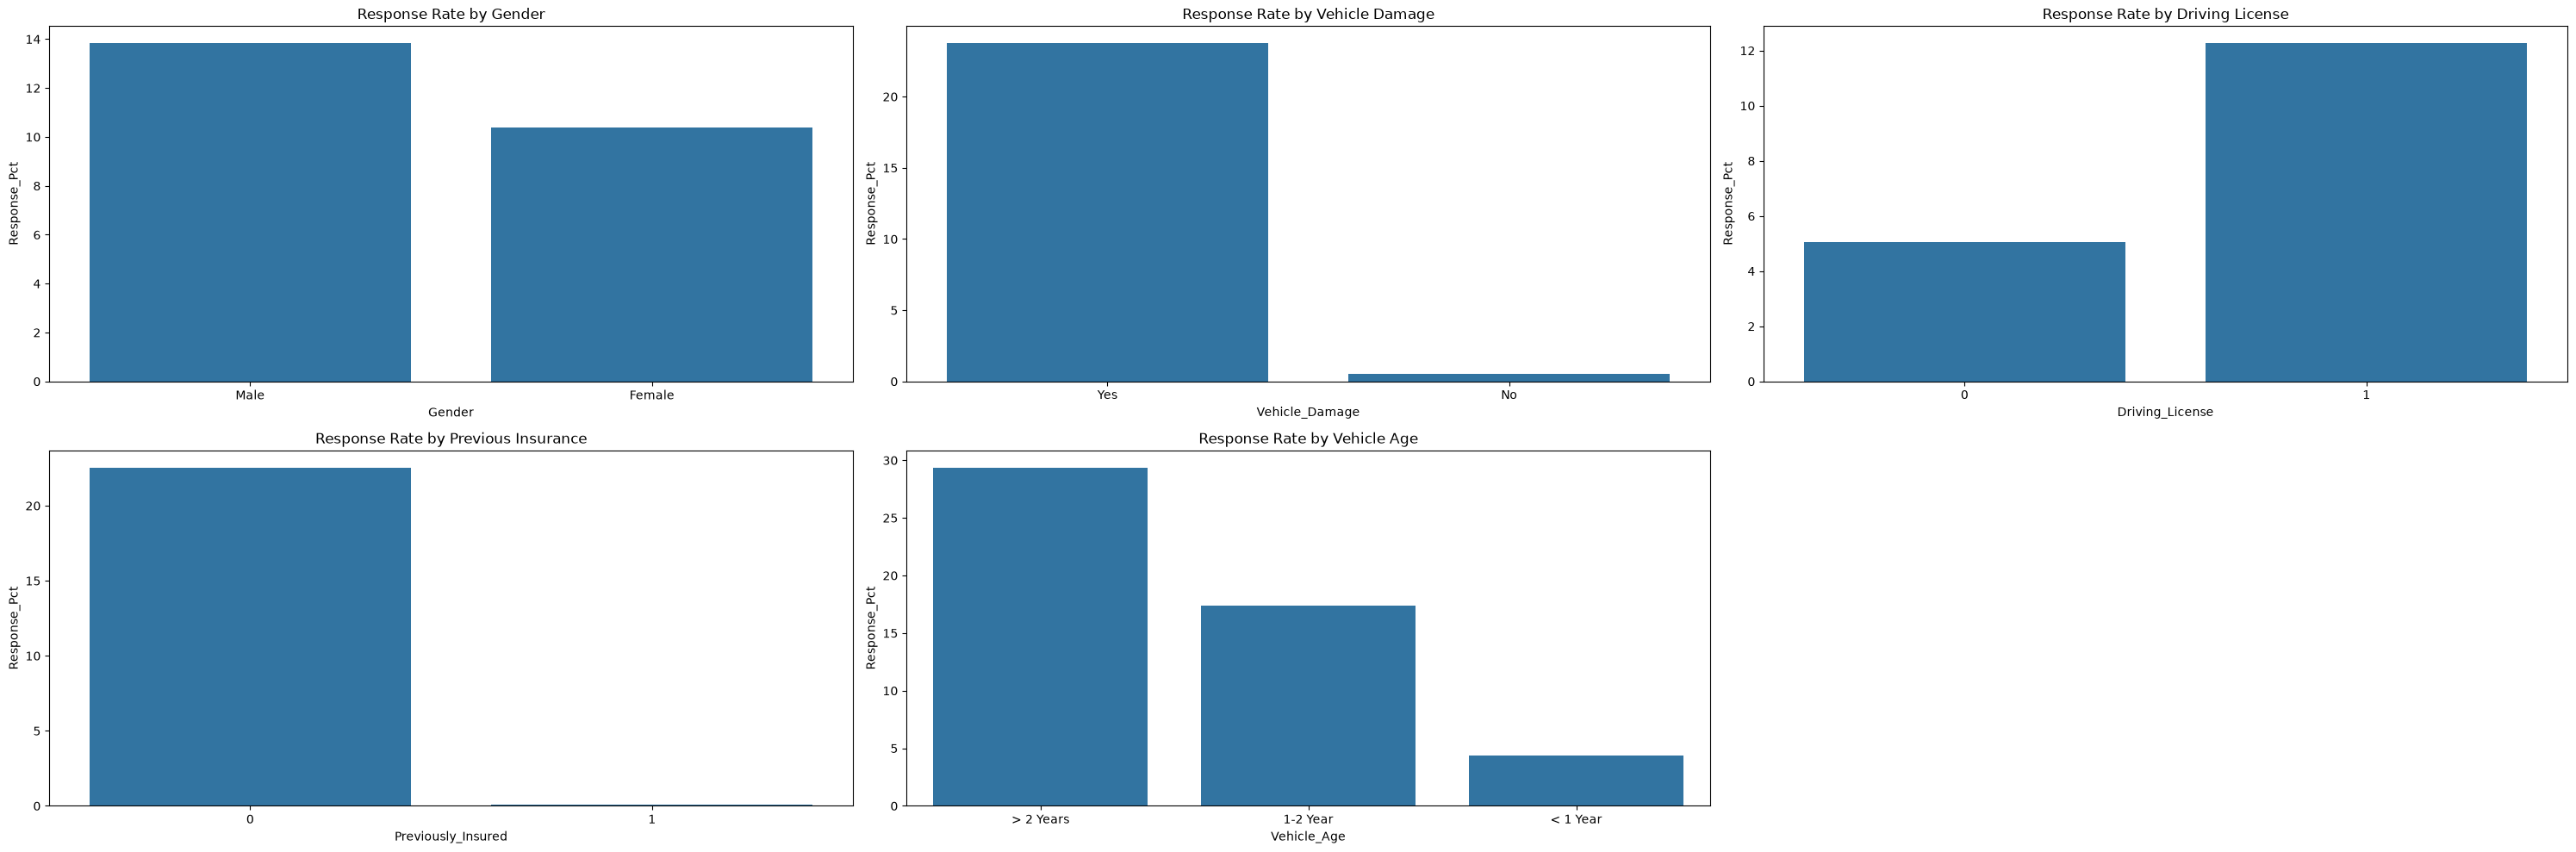

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(30, 10))

response_pct = train['Response'] * 100  # local series, not stored on train

# Gender vs Response
sns.barplot(data=train.assign(Response_Pct=response_pct), x='Gender', y='Response_Pct', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Response Rate by Gender')

# Damage vs Response
sns.barplot(data=train.assign(Response_Pct=response_pct), x='Vehicle_Damage', y='Response_Pct', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Response Rate by Vehicle Damage')

# Drivers license vs Response
sns.barplot(data=train.assign(Response_Pct=response_pct), x='Driving_License', y='Response_Pct', ax=axes[0, 2], errorbar=None)
axes[0, 2].set_title('Response Rate by Driving License')

# Previously Insured vs Response
sns.barplot(data=train.assign(Response_Pct=response_pct), x='Previously_Insured', y='Response_Pct', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Response Rate by Previous Insurance')

# Vehicle Age vs Response
sns.barplot(data=train.assign(Response_Pct=response_pct), x='Vehicle_Age', y='Response_Pct', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Response Rate by Vehicle Age')

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()



In [17]:
Policy_Sales_Channel_Analysis = pd.crosstab(train['Policy_Sales_Channel'], train['Response'], margins=True)
Policy_Sales_Channel_Analysis.columns = ['No', 'Yes', 'Total']
Policy_Sales_Channel_Analysis['Response_Rate (%)'] = ((Policy_Sales_Channel_Analysis['Yes'] / Policy_Sales_Channel_Analysis['Total']) * 100).round(2)
Policy_Sales_Channel_Analysis

,No,Yes,Total,Response_Rate (%)
Policy_Sales_Channel,,,,
1.0,1039,35,1074,3.26
2.0,3,1,4,25.00
3.0,364,159,523,30.40
4.0,407,102,509,20.04
6.0,3,0,3,0.00
...,...,...,...,...
158.0,357,135,492,27.44
159.0,50,1,51,1.96
160.0,21304,475,21779,2.18


In [18]:
#Get channels with at least 100 total customers
percentage_of_policy_sales_channel = (train.groupby('Policy_Sales_Channel')['Response'].value_counts(normalize=True) * 100).round(2).unstack(fill_value=0).rename(columns= {0: 'No', 1:'Yes'}).reset_index() #Calculating the percentage of policy sales channel
valid_channels = train['Policy_Sales_Channel'].value_counts()
valid_channels = valid_channels[valid_channels >= 100].index

#Filter, sort by column 1 ('Yes' rate) descending, and take top 10
top_Response_data = (percentage_of_policy_sales_channel[percentage_of_policy_sales_channel['Policy_Sales_Channel'].isin(valid_channels)].sort_values(by='Yes', ascending=False).head(10).rename(columns= {0: 'No', 1:'Yes'}).reset_index(drop=True))
top_Response_data

Response,Policy_Sales_Channel,No,Yes
0,155.0,67.99,32.01
1,163.0,69.58,30.42
2,3.0,69.60,30.40
3,158.0,72.56,27.44
4,157.0,73.16,26.84
5,31.0,74.64,25.36
6,154.0,75.40,24.60
7,150.0,75.64,24.36
8,136.0,78.38,21.62
9,156.0,78.45,21.55


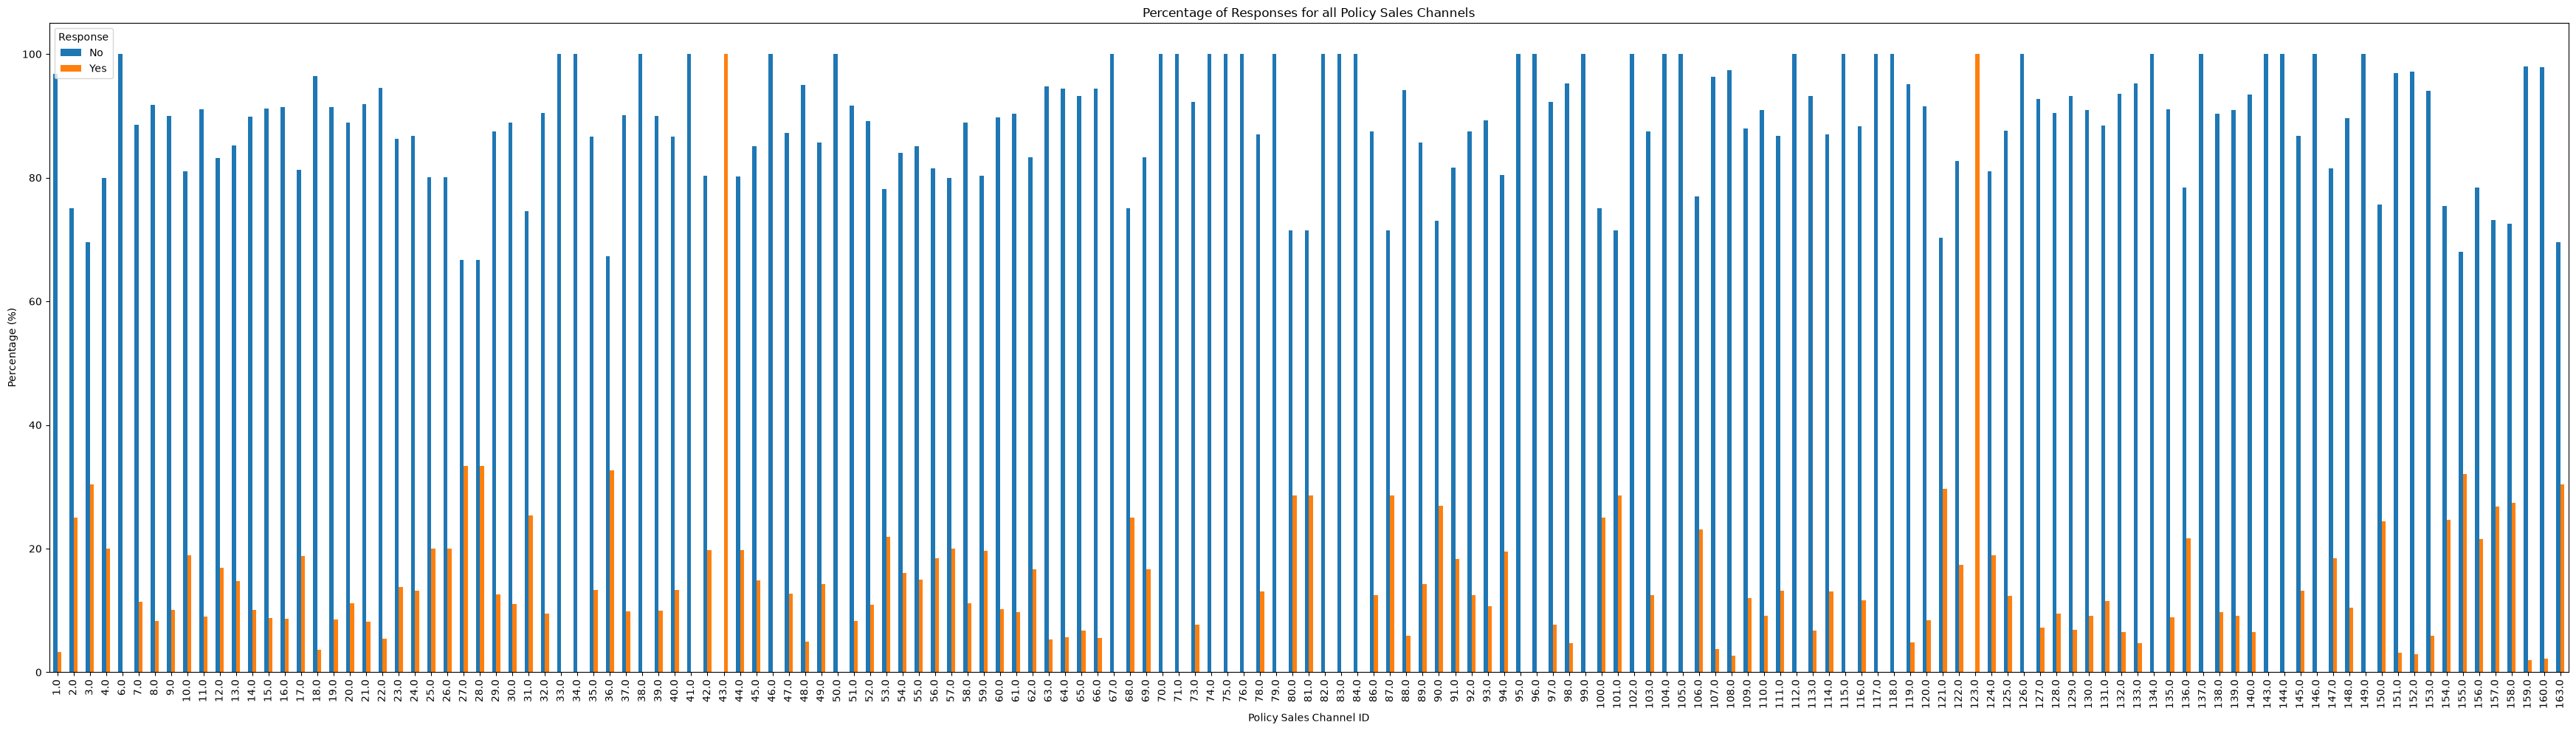

In [19]:
percentage_of_policy_sales_channel.columns.name = None
percentage_of_policy_sales_channel.plot(kind='bar', x='Policy_Sales_Channel', y=['No', 'Yes'], figsize=(35,10))
plt.title('Percentage of Responses for all Policy Sales Channels')
plt.xlabel('Policy Sales Channel ID')
plt.ylabel('Percentage (%)')
plt.legend(title='Response', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(train['Policy_Sales_Channel'] == 43.0, train['Response']).rename(columns= {0: 'No', 1:'Yes'}).reset_index()

Response,Policy_Sales_Channel,No,Yes
0,False,334399,46709
1,True,0,1


In [21]:
pd.crosstab(train['Policy_Sales_Channel'] == 123.0, train['Response']).rename(columns= {0: 'No', 1:'Yes'}).reset_index()

Response,Policy_Sales_Channel,No,Yes
0,False,334399,46709
1,True,0,1


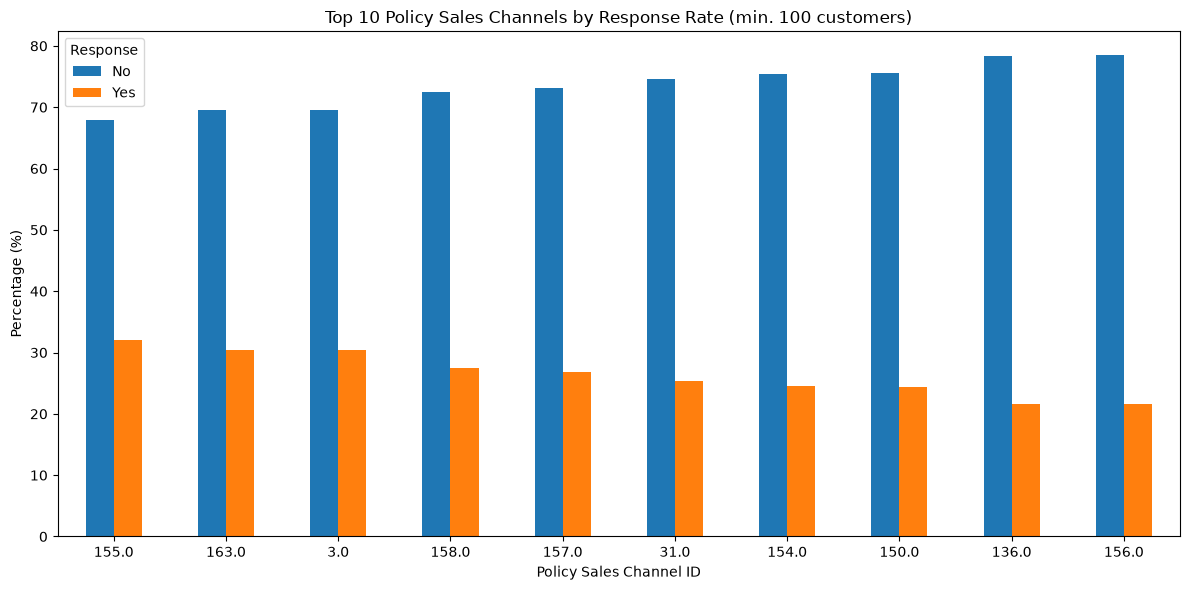

In [22]:
top_Response_data.columns.name = None
top_Response_data.plot(kind='bar', x='Policy_Sales_Channel', y=['No', 'Yes'], figsize=(12, 6))
plt.title('Top 10 Policy Sales Channels by Response Rate (min. 100 customers)')
plt.xlabel('Policy Sales Channel ID')
plt.ylabel('Percentage (%)')
plt.legend(title='Response', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset contains 155 unique Policy Sales Channels. While some channels appear to show a perfect 100% "Yes" response rate, this is misleading checking these channels individually revealed they had only 1 customer each (e.g., Channel 43.0 and 123.0 had exactly 1 customer, who responded "Yes"). 
These channels were excluded from consideration as top performers.
After filtering to channels with at least 100 customers (to ensurea minimum sample size threshold used to reduce the influence of extremely small groups.), the top 10 Policy Sales Channels by response rate are: 155.0 (32.01%), 163.0 (30.42%), 3.0 (30.40%), 158.0 (27.44%), 157.0 (26.84%), 31.0 (25.36%), 154.0 (24.60%), 150.0 (24.36%), 136.0 (21.62%), and 156.0 (21.55%).

In [23]:
train['Age'].unique()


array([44, 76, 47, 21, 29, 24, 23, 56, 32, 41, 71, 37, 25, 42, 60, 65, 49,
       34, 51, 26, 57, 79, 48, 45, 72, 30, 54, 27, 38, 22, 78, 20, 39, 62,
       58, 59, 63, 50, 67, 77, 28, 69, 52, 31, 33, 43, 36, 53, 70, 46, 55,
       40, 61, 75, 64, 35, 66, 68, 74, 73, 84, 83, 81, 80, 82, 85])

In [24]:
#Put the age in bins 
bins = [19, 29, 39, 49, 59, float('inf')]

# Create 10-year age groups for easier analysis
labels = ['20–29', '30–39', '40–49', '50–59', '60+'] 

train['Age_bin'] = pd.cut(train['Age'],bins=bins,labels=labels)

train[['Age', 'Age_bin']].head()

,Age,Age_bin
0,44,40–49
1,76,60+
2,47,40–49
3,21,20–29
4,29,20–29


In [25]:
#Calculating the percentage of each age bracket to response
percentage_age_bracket= (train.groupby('Age_bin', observed=True)['Response'].value_counts(normalize=True)*100).round(2).unstack(fill_value=0).rename(columns= {0: 'No', 1:'Yes'}).reset_index()
percentage_age_bracket

Response,Age_bin,No,Yes
0,20–29,95.89,4.11
1,30–39,79.99,20.01
2,40–49,78.76,21.24
3,50–59,82.31,17.69
4,60+,90.03,9.97


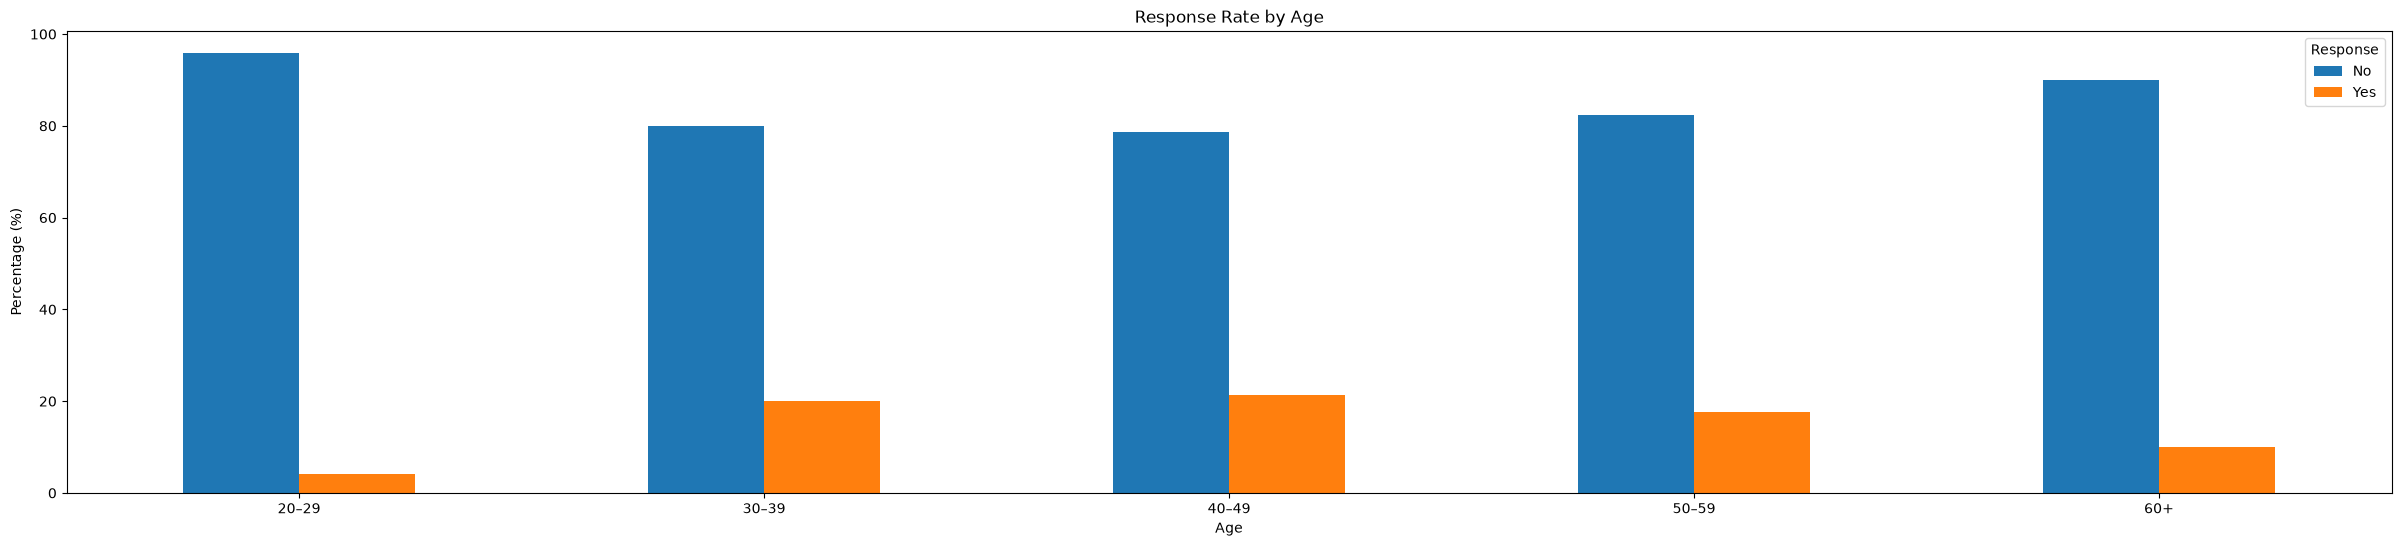

In [26]:
percentage_age_bracket.columns.name = None
percentage_age_bracket.plot(kind= 'bar' , x='Age_bin', y=['No', 'Yes'], figsize=(30,6))
plt.title('Response Rate by Age')
plt.xlabel('Age')
plt.ylabel('Percentage (%)')
plt.legend(title='Response', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

Response is low among the youngest customers (~3-6% for ages 20-29), rises sharply through the late 20s, and peaks around ages 33-36 (~22-23%). It then holds roughly steady through the low 50s before gradually declining into the senior years.

### Key Bivariate Observations

- **Gender**: Males respond at a higher rate than females (13.84% vs 10.39%).
- **Vehicle_Damage**: This is one of the strongest signal in the dataset, customers with prior vehicle damage convert at 23.77%, compared to just 0.52% for those without.
- **Vehicle_Age**: Response increases with vehicle age 4.37% (<1 year), 17.38% (1-2 years), 29.37% (>2 years). Note, however, that the >2 years group is also the smallest segment (only 4.20% of customers), while the 1-2 year group is both the largest (52.56%) and moderately converting likely the highest-volume opportunity for improving response.
- **Previously_Insured**: A dramatic gap customers not currently insured convert at 22.55%, versus just 0.09% for those already insured. This strongly suggests Previously Insured is one of the most important features in the dataset.
- **Driving_License**: Customers with a license convert more (12.27% vs 5.05%), only ~0.21% of the dataset lacks a license (roughly 812 customers), so the no-license group's rate is based on a small sample and may not generalize.
- **Age**: Response is low among the youngest customers (~3-6% for ages 20-27), rises sharply through the late 20s and early 30s, plateaus at its highest level (20-23%) between ages 35-50, then gradually declines through the senior years.
- **Policy_Sales_Channel**: Despite having 155 unique Policy Sales channel, the top 10 channels are 155.0 with 32.01%, 163.0 with 30.42%, 3.0 with 30.40%, 158.0 with 27.44%, 157.0 with 26.84%, 31.0 with 25.36%, 154.0 with 24.60%,150.0 with 24.36%,136.0 with 21.62%,156.0 with 21.55%

## Multivariate Analysis

This section examines multiple customer characteristics together to determine whether combinations of factors provide deeper insight into customers' likelihood of expressing interest in vehicle insurance. The analysis focuses on variables that showed meaningful relationships with "Response" during the bivariate analysis.
**NB:** I will be using initials for the variable combinations:
- vpr: Vehicle_Damage, Previously_Insured, Response
- vvr: Vehicle_Age, Vehicle_Damage, Response
- avr: Age_bin, Vehicle_Damage, Response
- gvr: Gender, Vehicle_Damage, Response
- par: Previously_Insured, Age_bin, Response
- pvr: Previously_Insured, Vehicle_Age, Response
- agr: Age_bin, Gender, Response
- vpar: Vehicle_Damage, Previously_Insured, Age_bin, Response
- pvpr: Policy_Sales_Channel, Vehicle_Damage, Previously_Insured
- avvpr: Age_bin, Vehicle_Age, Vehicle_Damage, Previously_Insured, Response

In [27]:

vpr = (pd.crosstab([train['Vehicle_Damage'], train['Previously_Insured']], train['Response'], margins=True).rename(columns={0: 'No', 1: 'Yes'}).rename_axis(columns=None))
vpr['Response_Rate (%)'] = ((vpr['Yes'] / vpr['All']) * 100).round(2)
vpr

No    Yes     All  Response_Rate (%)
Vehicle_Damage Previously_Insured                                          
No             0                    23080    910   23990               3.79
               1                   164634     72  164706               0.04
Yes            0                   136849  45642  182491              25.01
               1                     9836     86    9922               0.87
All                                334399  46710  381109              12.26

Customers with vehicle damage and no previous insurance showed the highest response rate at 25.01%. In contrast, previously insured customers had very low response rates regardless of vehicle damage rising only from 0.04% to 0.87% with damage while among not-previously-insured customers, vehicle damage had a much larger effect (3.79% to 25.01%). This suggests Previously Insured is a dominant factor: it sets a ceiling on the likelihood that Vehicle Damage can only meaningfully influence when a customer is not already insured.

In [28]:
vvr = (pd.crosstab([train['Vehicle_Age'], train['Vehicle_Damage']], train['Response'], margins=True).rename(columns={0: 'No', 1: 'Yes'}).rename_axis(columns=None))
vvr['Response_Rate (%)'] = ((vvr['Yes'] / vvr['All']) * 100).round(2)
vvr

No    Yes     All  Response_Rate (%)
Vehicle_Age Vehicle_Damage                                          
1-2 Year    No               71495    596   72091               0.83
            Yes              94015  34210  128225              26.68
< 1 Year    No              116204    386  116590               0.33
            Yes              41380   6816   48196              14.14
> 2 Years   No                  15      0      15               0.00
            Yes              11290   4702   15992              29.40
All                         334399  46710  381109              12.26

Cross-tabulating Vehicle_Age and Vehicle_Damage against Response shows that prior damage is the dominant observed association of positive response, vehicle age alone has almost no effect.

| Vehicle Age | No Damage | Damage |
|---|---|---|
| < 1 Year   | 0.33%  | 14.14% |
| 1-2 Years  | 0.83%  | 26.68% |
| > 2 Years  | 0.00%  | 29.40% |


- Customers with no vehicle damage almost never respond positively (<1% across all age groups).
- Among damaged vehicles, response rate rises with vehicle age older + damaged converts nearly 2x more than newer + damaged.
- Vehicle Damage should be treated as a high-priority feature for this analysis; Vehicle Age mainly adds value as an interaction term with damage.
- Customers with older Vehicle Age of 1 and above gave a positive response compared to those with <1 year

In [29]:
avr = (pd.crosstab([train['Age_bin'], train['Vehicle_Damage']], train['Response'], margins=True).rename(columns={0: 'No', 1: 'Yes'}). rename_axis(columns=None))
avr['Response_Rate (%)'] = ((avr['Yes'] / avr['All']) * 100).round(2)
avr

No    Yes     All  Response_Rate (%)
Age_bin Vehicle_Damage                                          
20–29   No              108096    364  108460               0.34
        Yes              40733   6010   46743              12.86
30–39   No               22547    275   22822               1.20
        Yes              20850  10581   31431              33.66
40–49   No               23788    202   23990               0.84
        Yes              36739  16117   52856              30.49
50–59   No               15280    102   15382               0.66
        Yes              24257   8395   32652              25.71
60+     No               18003     39   18042               0.22
        Yes              24106   4625   28731              16.10
All                     334399  46710  381109              12.26

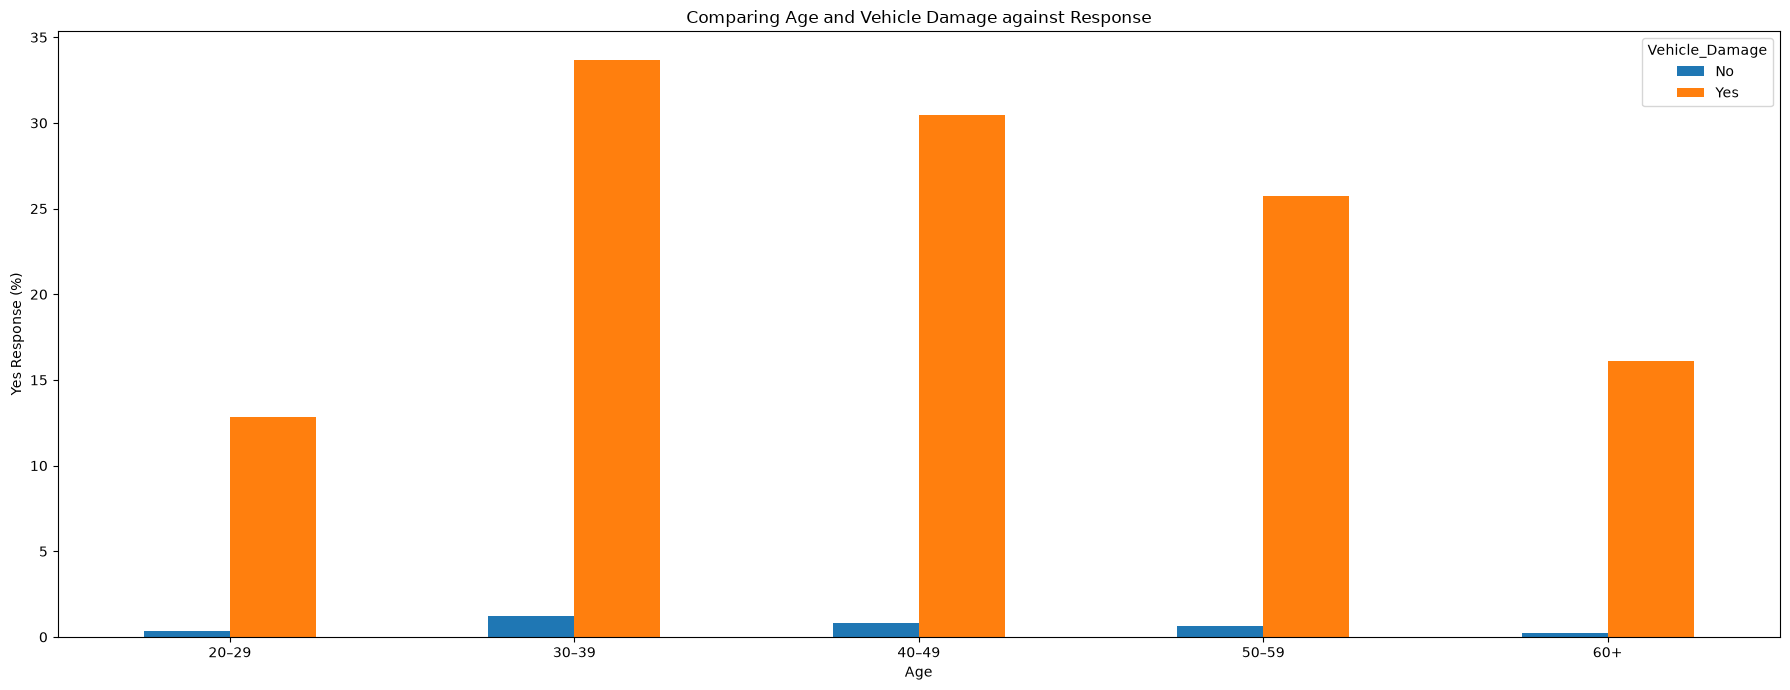

In [30]:
avr = (train.groupby(['Age_bin', 'Vehicle_Damage'])['Response'].value_counts(normalize = True) * 100).unstack(fill_value = 0).rename(columns= {0: 'No', 1:'Yes'}).reset_index()
avr_pivot = avr.pivot(index='Age_bin', columns='Vehicle_Damage', values='Yes')

avr_pivot.plot(kind='bar', stacked=False, figsize=(18, 7))
plt.xlabel('Age')
plt.ylabel('Yes Response (%)')
plt.title('Comparing Age and Vehicle Damage against Response')
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

The chart shows the "Yes" response rate (%) for each individual Age, split by Vehicle_Damage. As before, damage remains the dominant variable the "No damage" bars stay near zero across every age but within the "damaged" group, age reveals a clear non-linear pattern.


- Response rate rises sharply through the 20s and peaks in the early-to-mid 30s, hitting its highest point (~37%) around age 33–34, before beginning a steady decline.
- Younger customers (20–25) with vehicle damage still respond far less (under ~15%) than their 30s counterparts age alone is not the variable, but it interacts strongly with damageup to a point.
- After the low-to-mid 30s peak, response rate declines gradually through the 40s–60s, settling into a lower, noisier band (~10–20%) for older ages.
- Past ~age 75, the data gets sparse and volatile small sample sizes per age likely explain the erratic spikes/dips rather than a genuine behavioral shift.
- No-damage customers are consistently near 0% across the entire age range, reinforcing that Vehicle_Damage is the primary signal, with Age acting mainly as a secondary, non-linear modifier (an inverted-U shape) rather than a simple increasing/decreasing trend.


In [31]:
gvr = (pd.crosstab([train['Gender'], train['Vehicle_Damage']], train['Response'],margins = True).rename(columns={0: 'No', 1: 'Yes'}).rename_axis(columns=None))
gvr['Response_Rate (%)'] = ((gvr['Yes'] / gvr['All']) * 100).round(2)
gvr

No    Yes     All  Response_Rate (%)
Gender Vehicle_Damage                                          
Female No               94937    418   95355               0.44
       Yes              61898  17767   79665              22.30
Male   No               92777    564   93341               0.60
       Yes              84787  27961  112748              24.80
All                    334399  46710  381109              12.26

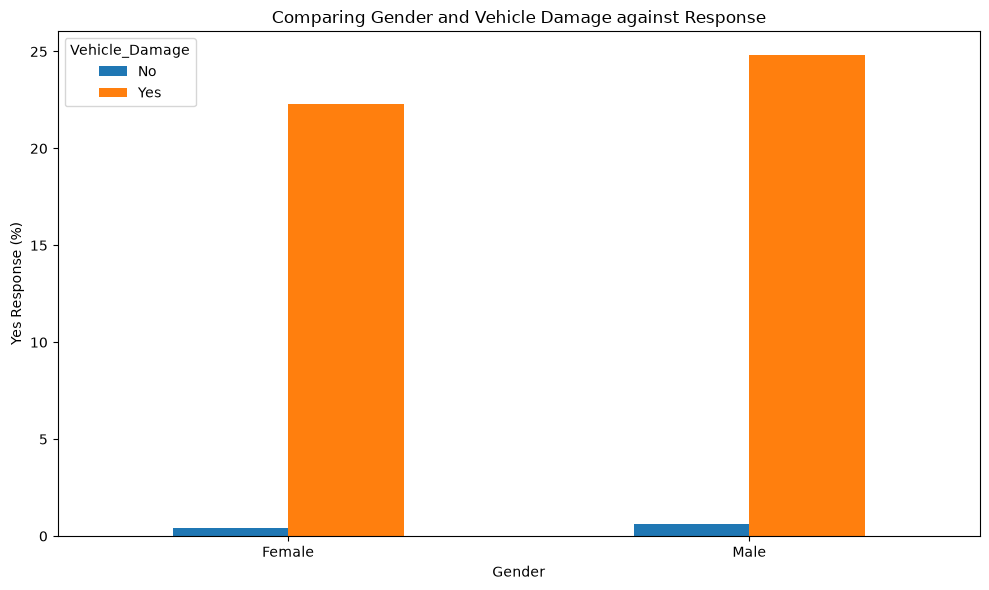

In [32]:
gvr = (train.groupby(['Gender', 'Vehicle_Damage'])['Response'].value_counts(normalize = True) * 100).unstack(fill_value = 0).rename(columns= {0: 'No', 1:'Yes'}).reset_index()
gvr_pivot = gvr.pivot(index='Gender', columns='Vehicle_Damage', values='Yes')

gvr_pivot.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.xlabel('Gender')
plt.ylabel('Yes Response (%)')
plt.title('Comparing Gender and Vehicle Damage against Response')
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

The "gvr" breakdown shows that Gender plays a minor role compared to the stronger drivers identified earlier Vehicle Damage and Previously Insured remain far more decisive for a positive response. That said, males do dominate females in this data, both in volume and in response rate (24.80% vs 22.30% among damaged vehicles).

In [33]:
par = (pd.crosstab([train['Previously_Insured'], train['Age_bin']], train['Response'], margins = True).rename(columns = {0: 'No', 1: 'Yes'}). rename_axis(columns=None))
par['Response_Rate (%)'] = ((par['Yes'] / par['All']) * 100).round(2)
par

No    Yes     All  Response_Rate (%)
Previously_Insured Age_bin                                          
0                  20–29     46810   6314   53124              11.89
                   30–39     23062  10813   33875              31.92
                   40–49     39608  16279   55887              29.13
                   50–59     25452   8491   33943              25.02
                   60+       24997   4655   29652              15.70
1                  20–29    102019     60  102079               0.06
                   30–39     20335     43   20378               0.21
                   40–49     20919     40   20959               0.19
                   50–59     14085      6   14091               0.04
                   60+       17112      9   17121               0.05
All                         334399  46710  381109              12.26

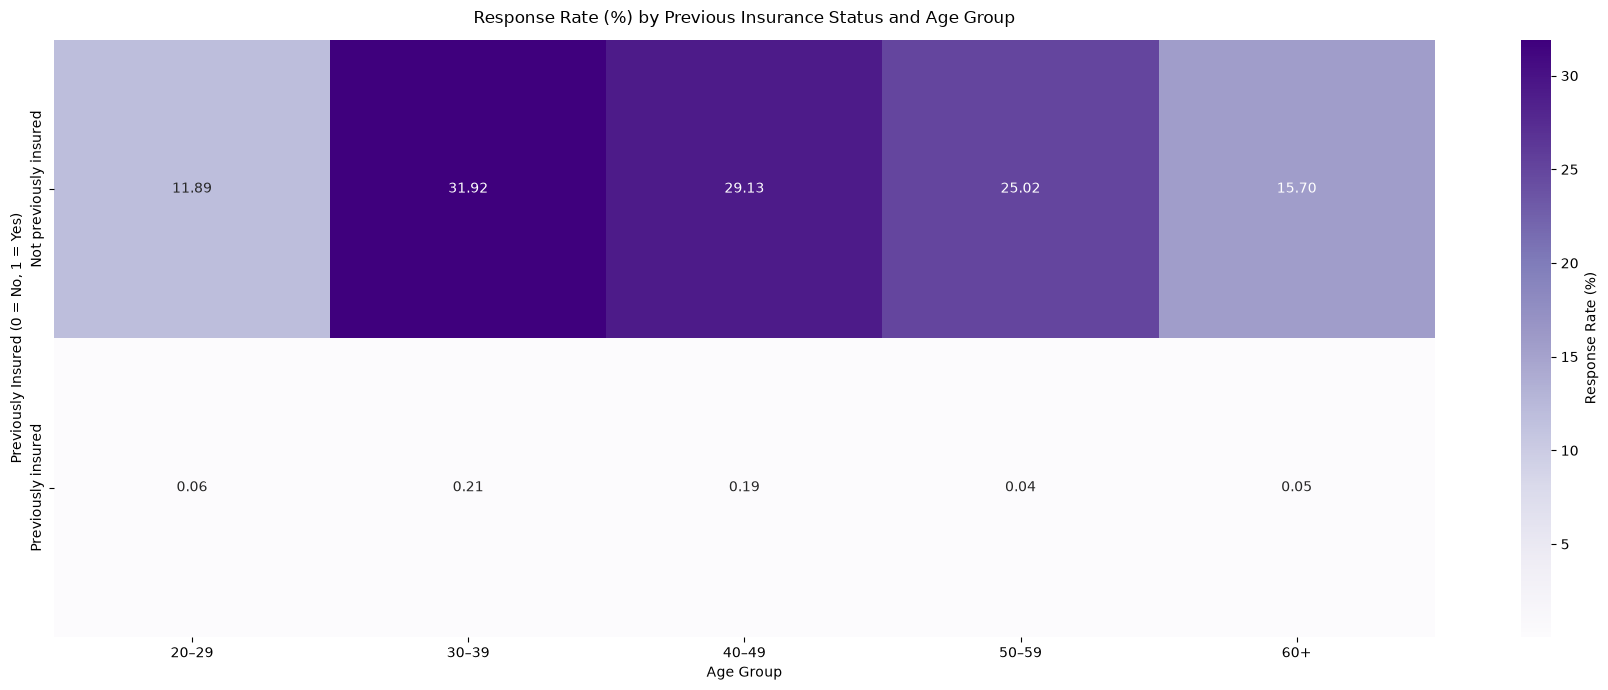

In [34]:
# 1. Reset index and drop summary rows/margins
par_clean = par.reset_index()
par_clean = par_clean[(par_clean['Previously_Insured'] != 'All') & (par_clean['Age_bin'] != 'All')]

# 2. Pivot into a clean 2D matrix (Rows: Previously_Insured, Cols: Age_bin)
par_matrix = par_clean.pivot(index='Previously_Insured', columns='Age_bin', values='Response_Rate (%)').rename(index={0: 'Not previously insured', 1: 'Previously insured'})

# 3. Plot the heat map with proper scaling
plt.figure(figsize=(18, 7))
sns.heatmap(par_matrix,annot=True,fmt='.2f',cmap='Purples',cbar_kws={'label': 'Response Rate (%)'},)
plt.title('Response Rate (%) by Previous Insurance Status and Age Group', pad=12)
plt.xlabel('Age Group')
plt.ylabel('Previously Insured (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

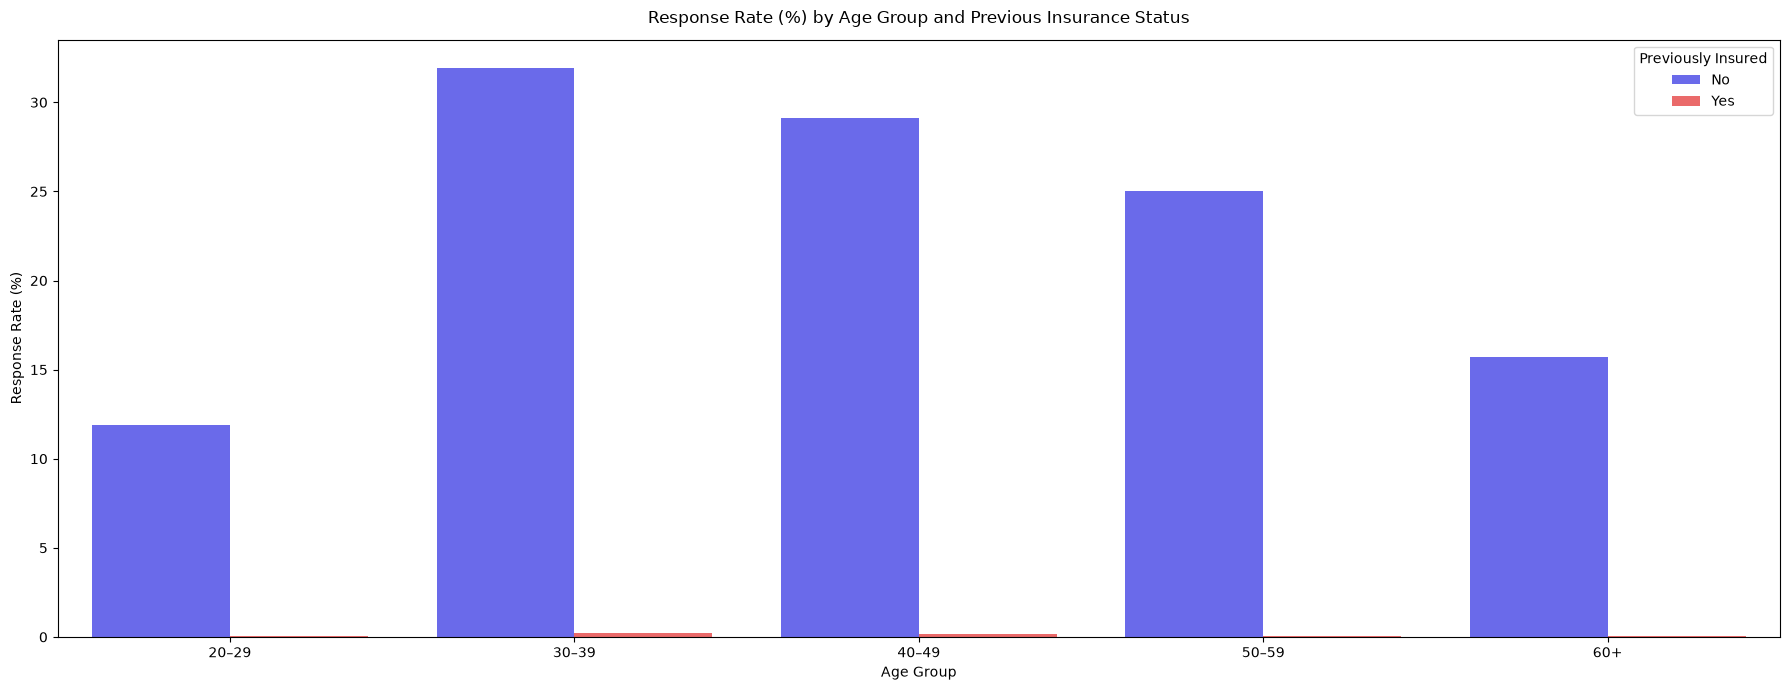

In [35]:
# For the Bar chart visualiztion 
par_flat = par.reset_index()
par_flat = par_flat[(par_flat['Previously_Insured'] != 'All') & (par_flat['Age_bin'] != 'All')]
par_flat['Previously_Insured_Label'] = par_flat['Previously_Insured'].map({0: 'No', 1: 'Yes'})
plt.figure(figsize=(18, 7))
sns.barplot(data=par_flat,x='Age_bin',y='Response_Rate (%)',hue='Previously_Insured_Label',palette='seismic')
plt.title('Response Rate (%) by Age Group and Previous Insurance Status', pad=12)
plt.xlabel('Age Group')
plt.ylabel('Response Rate (%)')
plt.legend(title='Previously Insured')
plt.tight_layout()
plt.show()

The par breakdown confirms what we've seen throughout: Previously Insured overwhelms Age as a driver of response. Among 'not previously insured' customers, response follows a clear non-linear pattern with age it starts low at 20-29 (11.89%), peaks at 30-39 (31.92%), and declines steadily through 40-49 (29.13%), 50-59 (25.02%), and 60+ (15.70%). Previously insured customers, by contrast, stay under 0.25% across every single age group, showing that once a customer already has insurance, age has essentially no influence on their likelihood to respond.

In [36]:
pvr = (pd.crosstab([train['Previously_Insured'], train['Vehicle_Age']], train['Response'], margins = True).rename(columns = {0: 'No', 1: 'Yes'}). rename_axis(columns=None))
pvr['Response_Rate (%)'] = ((pvr['Yes'] / pvr['All']) * 100).round(2)
pvr

No    Yes     All  Response_Rate (%)
Previously_Insured Vehicle_Age                                          
0                  1-2 Year     100280  34711  134991              25.71
                   < 1 Year      48389   7140   55529              12.86
                   > 2 Years     11260   4701   15961              29.45
1                  1-2 Year      65230     95   65325               0.15
                   < 1 Year     109195     62  109257               0.06
                   > 2 Years        45      1      46               2.17
All                             334399  46710  381109              12.26

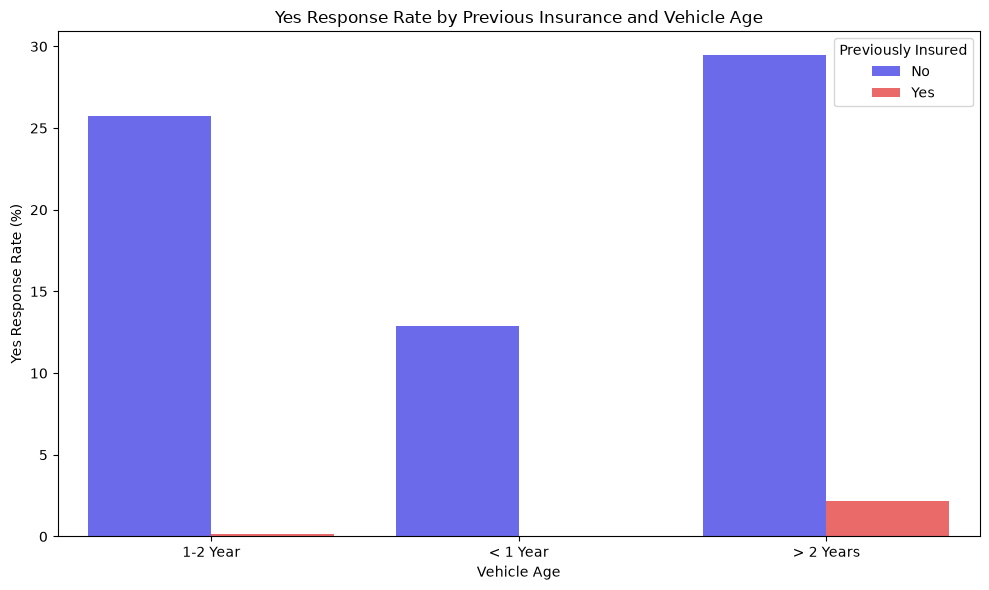

In [37]:
plot_data = pvr.drop('All').reset_index()
plot_data['Previously_Insured'] = plot_data['Previously_Insured'].map({0: 'No', 1: 'Yes'})
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data,x='Vehicle_Age',y='Response_Rate (%)',hue='Previously_Insured',palette='seismic')
plt.title('Yes Response Rate by Previous Insurance and Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Yes Response Rate (%)')
plt.legend(title= 'Previously Insured')
plt.tight_layout()
plt.show()

The 'pvr' breakdown reinforces the same pattern seen with age: Previously_Insured remains one of the strongest observed associations with response, with Vehicle_Age adding a secondary effect within the 'not previously insured' group. Among customers without prior insurance, response rises with vehicle age 12.86% for cars under 1 year, up to 25.71% for 1-2 years, and 29.45% for vehicles over 2 years old. Previously insured customers stay far lower across all three groups (0.06%-0.15%), consistent with our earlier finding that prior insurance status caps how much any other variable can move response.

In [38]:
agr = (pd.crosstab([train['Age_bin'], train['Gender']], train['Response'], margins = True).rename(columns = {0: 'No', 1: 'Yes'}).rename_axis(columns=None))
agr['Response_Rate (%)'] = ((agr['Yes'] / agr['All']) * 100).round(2)
agr

No    Yes     All  Response_Rate (%)
Age_bin Gender                                          
20–29   Female   83202   2896   86098               3.36
        Male     65627   3478   69105               5.03
30–39   Female   19954   4722   24676              19.14
        Male     23443   6134   29577              20.74
40–49   Female   23480   6218   29698              20.94
        Male     37047  10101   47148              21.42
50–59   Female   13441   2651   16092              16.47
        Male     26096   5846   31942              18.30
60+     Female   16758   1698   18456               9.20
        Male     25351   2966   28317              10.47
All             334399  46710  381109              12.26

The agr breakdown shows Gender adds only a small, consistent shift on top of the Age pattern already established Males respond at a slightly higher rate than females in every age bin, with the gap ranging from about 1 to 2 points (e.g. 20.94% vs 21.42% at 40-49, 16.47% vs 18.30% at 50-59). Unconditioned on Previously Insured, response peaks at 40-49 (20.94%-21.42%) rather than 30-39, consistent with the earlier univariate finding of a plateau across ages 35-50. The steepest relative jump is between 20-29 and 30-39, where response rate roughly quintuples for both genders.

In [39]:
vpar = (pd.crosstab([train['Vehicle_Damage'],train['Previously_Insured'],train['Age_bin']], train['Response'], margins= True).rename(columns= {0: 'No', 1: 'Yes'}).rename_axis(columns=None))
vpar['Response_Rate (%)'] = ((vpar['Yes'] / vpar['All']) * 100).round(2)
vpar

No    Yes     All  \
Vehicle_Damage Previously_Insured Age_bin                          
No             0                  20–29     10133    338   10471   
                                  30–39      3368    253    3621   
                                  40–49      4513    183    4696   
                                  50–59      2475    101    2576   
                                  60+        2591     35    2626   
               1                  20–29     97963     26   97989   
                                  30–39     19179     22   19201   
                                  40–49     19275     19   19294   
                                  50–59     12805      1   12806   
                                  60+       15412      4   15416   
Yes            0                  20–29     36677   5976   42653   
                                  30–39     19694  10560   30254   
                                  40–49     35095  16096   51191   
                                  50–59     22977   8390   31367   
                                  60+       22406   4620   27026   
               1                  20–29      4056     34    4090   
                                  30–39      1156     21    1177   
                                  40–49      1644     21    1665   
                                  50–59      1280      5    1285   
                                  60+        1700      5    1705   
All                                        334399  46710  381109   

                                           Response_Rate (%)  
Vehicle_Damage Previously_Insured Age_bin                     
No             0                  20–29                 3.23  
                                  30–39                 6.99  
                                  40–49                 3.90  
                                  50–59                 3.92  
                                  60+                   1.33  
               1                  20–29                 0.03  
                                  30–39                 0.11  
                                  40–49                 0.10  
                                  50–59                 0.01  
                                  60+                   0.03  
Yes            0                  20–29                14.01  
                                  30–39                34.90  
                                  40–49                31.44  
                                  50–59                26.75  
                                  60+                  17.09  
               1                  20–29                 0.83  
                                  30–39                 1.78  
                                  40–49                 1.26  
                                  50–59                 0.39  
                                  60+                   0.29  
All                                                    12.26

The three-way breakdown confirms that Vehicle Damage and Previously Insured compound rather than substitute for each other. The highest responding segment by far is damaged vehicles with no prior insurance, peaking at 34.90% for ages 30-39 and following the same inverted-U shape by age seen throughout this analysis. Every other combination stays far lower: undamaged and 'not insured' customers top out at 6.99% (30-39), while both previously insured groups regardless of damage status stay under 2% across all ages. This shows Age's influence is really only meaningful within the single highest-value segment (damaged, not-insured); everywhere else it barely moves the needle.

In [40]:
pvpr = (pd.crosstab([train['Policy_Sales_Channel'], train['Vehicle_Damage'], train['Previously_Insured']],train['Response'], margins=True).rename(columns= {0: 'No', 1: 'Yes'}).rename_axis(columns=None))
pvpr['Response_Rate (%)'] = ((pvpr['Yes'] / pvpr['All']) * 100).round(2)
pvpr

No    Yes     All  \
Policy_Sales_Channel Vehicle_Damage Previously_Insured                          
1.0                  No             0                      787     30     817   
                                    1                      167      2     169   
                     Yes            0                       77      2      79   
                                    1                        8      1       9   
2.0                  Yes            0                        3      1       4   
...                                                        ...    ...     ...   
163.0                No             0                       72     15      87   
                                    1                      236      0     236   
                     Yes            0                     1578    861    2439   
                                    1                      127      4     131   
All                                                     334399  46710  381109   

                                                        Response_Rate (%)  
Policy_Sales_Channel Vehicle_Damage Previously_Insured                     
1.0                  No             0                                3.67  
                                    1                                1.18  
                     Yes            0                                2.53  
                                    1                               11.11  
2.0                  Yes            0                               25.00  
...                                                                   ...  
163.0                No             0                               17.24  
                                    1                                0.00  
                     Yes            0                               35.30  
                                    1                                3.05  
All                                                                 12.26  

[494 rows x 4 columns]

In [41]:
avvpr = (pd.crosstab([train['Age_bin'], train['Vehicle_Age'], train['Vehicle_Damage'], train['Previously_Insured']], train['Response'], margins= True). rename(columns = {0: 'No', 1: 'Yes'}). rename_axis(columns=None))
avvpr['Response_Rate (%)'] = ((avvpr['Yes'] / avvpr['All']) * 100).round(2)
avvpr

No    Yes     All  \
Age_bin Vehicle_Age Vehicle_Damage Previously_Insured                          
20–29   1-2 Year    No             0                      481     47     528   
                                   1                     1190      0    1190   
                    Yes            0                     3020   1182    4202   
                                   1                      319      6     325   
        < 1 Year    No             0                     9652    291    9943   
                                   1                    96773     26   96799   
                    Yes            0                    33611   4784   38395   
                                   1                     3737     28    3765   
        > 2 Years   Yes            0                       46     10      56   
30–39   1-2 Year    No             0                     2445    206    2651   
                                   1                    10773     15   10788   
                    Yes            0                    15316   8377   23693   
                                   1                      935     20     955   
        < 1 Year    No             0                      923     47     970   
                                   1                     8406      7    8413   
                    Yes            0                     3727   1901    5628   
                                   1                      216      1     217   
        > 2 Years   Yes            0                      651    282     933   
                                   1                        5      0       5   
40–49   1-2 Year    No             0                     4312    175    4487   
                                   1                    19236     19   19255   
                    Yes            0                    32108  14359   46467   
                                   1                     1630     20    1650   
        < 1 Year    No             0                      196      8     204   
                                   1                       37      0      37   
                    Yes            0                       42     53      95   
                                   1                        2      0       2   
        > 2 Years   No             0                        5      0       5   
                                   1                        2      0       2   
                    Yes            0                     2945   1684    4629   
                                   1                       12      1      13   
50–59   1-2 Year    No             0                     2355     95    2450   
                                   1                    12788      1   12789   
                    Yes            0                    19649   6818   26467   
                                   1                     1270      5    1275   
        < 1 Year    No             0                      119      6     125   
                                   1                       13      0      13   
                    Yes            0                       32     41      73   
        > 2 Years   No             0                        1      0       1   
                                   1                        4      0       4   
                    Yes            0                     3296   1531    4827   
                                   1                       10      0      10   
60+     1-2 Year    No             0                     2513     34    2547   
                                   1                    15402      4   15406   
                    Yes            0                    18081   3418   21499   
                                   1                     1687      5    1692   
        < 1 Year    No             0                       76      1      77   
                                   1                        9      0       9   
                    Yes            0                       

This four way breakdown confirms the pattern holds even when segmented finely: the highest response rates cluster consistently in the "damaged vehicle, not previously insured" combination across every age and vehicle age group, while every previously insured combination stays in the low single digits or below regardless of damage or age. The best-supported peak is 30-39 / 1-2 Year / Damaged / Not Insured at 35.36% (n=23,693) the largest sample among the top-responding cells, making it the most reliable read of where response is highest. This is consistent with, and sharper than, the 30-39 peak seen in the two and three way breakdowns.

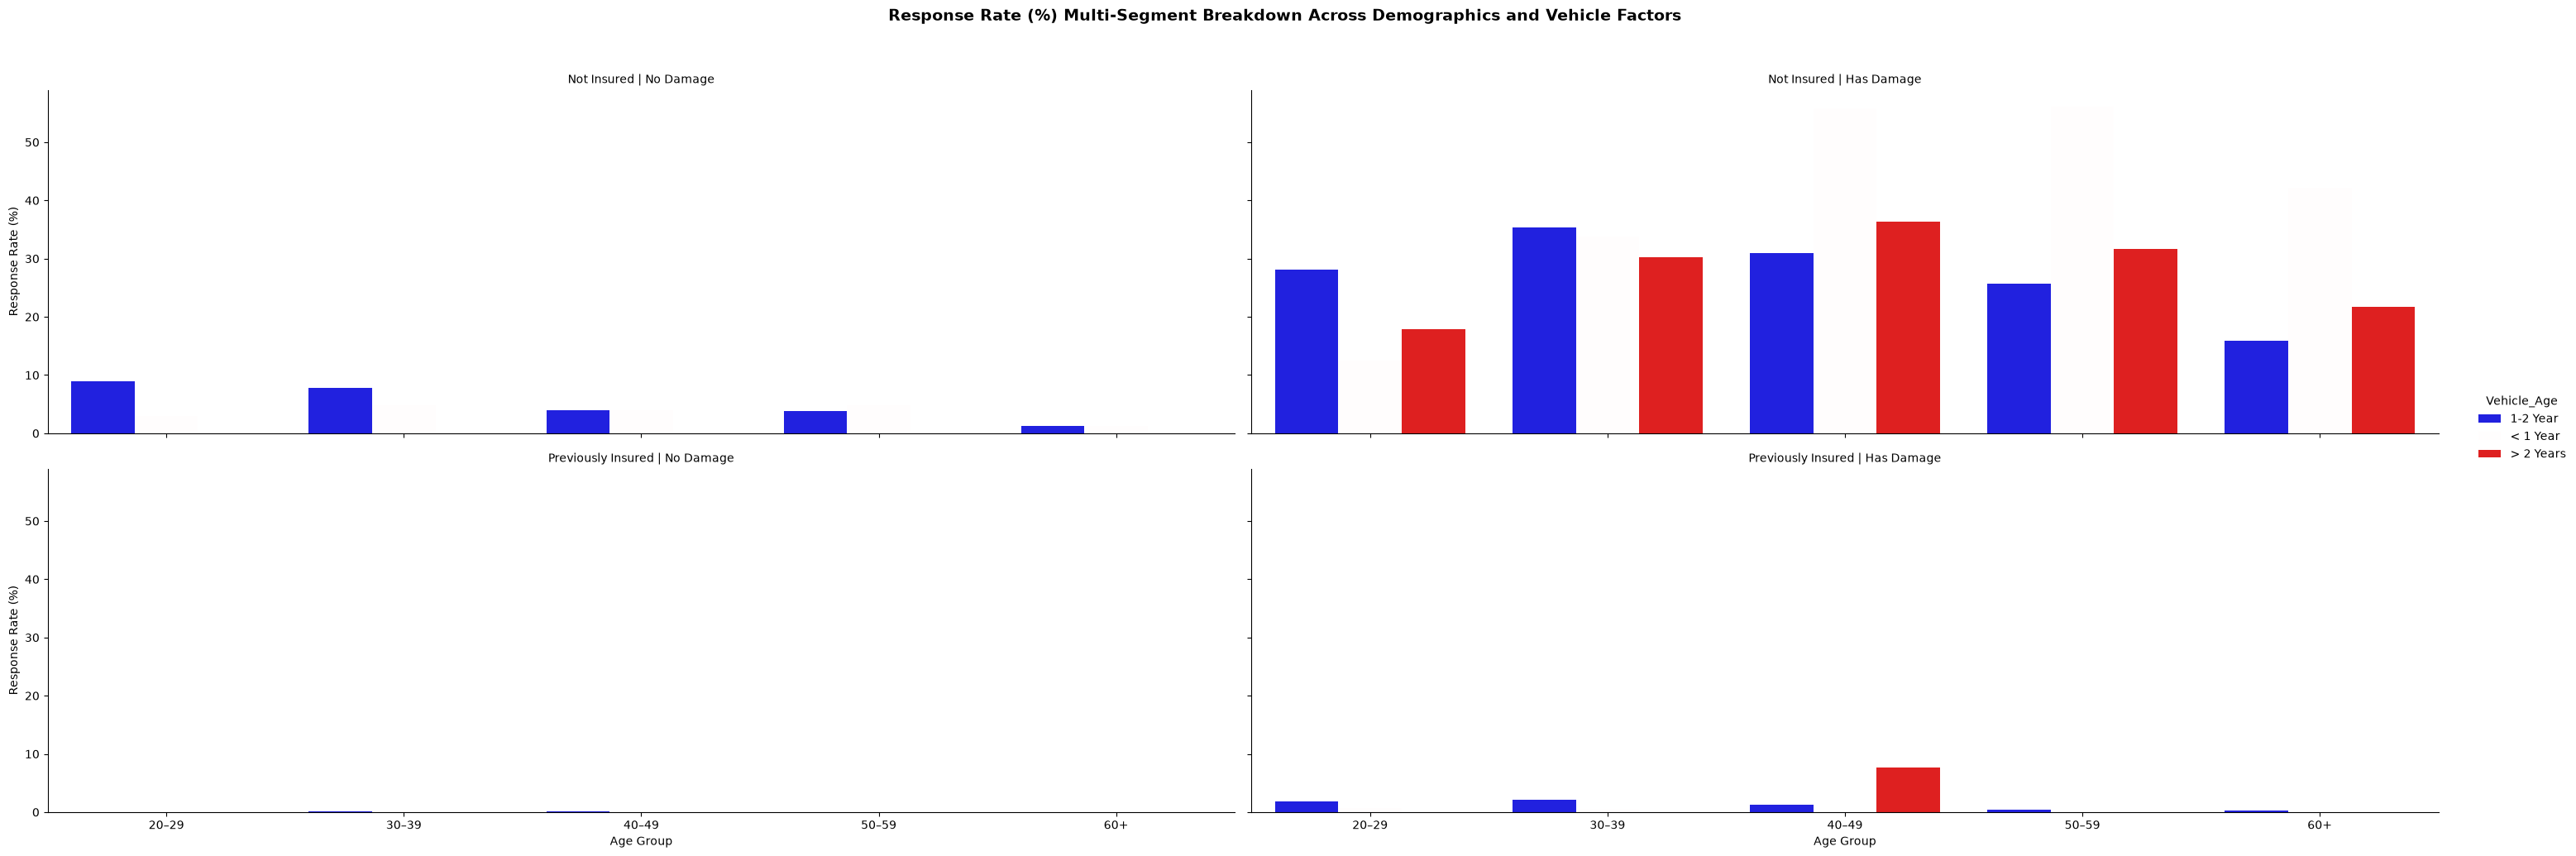

In [42]:
# 1. Flatten the 5-level MultiIndex and drop margin rows
avvpr_flat = avvpr.reset_index()
mask = ~(avvpr_flat.astype(str).isin(['All', ''])).any(axis=1)
avvpr_clean = avvpr_flat[mask].copy()

# 2. Map binary/categorical variables to human-readable strings
avvpr_clean['Previously_Insured_Label'] = avvpr_clean['Previously_Insured'].map({0: 'Not Insured', 1: 'Previously Insured', 'No': 'Not Insured', 'Yes': 'Previously Insured'})
avvpr_clean['Vehicle_Damage_Label'] = avvpr_clean['Vehicle_Damage'].map({0: 'No Damage', 1: 'Has Damage', 'No': 'No Damage', 'Yes': 'Has Damage'})

# Create a 2x2 grid of bar charts comparing Age_bin vs Response Rate
g = sns.catplot(
    data=avvpr_clean,
    x='Age_bin',
    y='Response_Rate (%)',
    hue='Vehicle_Age',
    col='Vehicle_Damage_Label',
    row='Previously_Insured_Label',
    kind='bar',
    palette='seismic',
    height=5,
    aspect=3,
    sharey=True,
)

g.fig.suptitle('Response Rate (%) Multi-Segment Breakdown Across Demographics and Vehicle Factors',y=1.03,fontsize=14,weight='bold',)
g.set_axis_labels('Age Group', 'Response Rate (%)')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.tight_layout()
plt.show()

This 2×2 grid shows the same story visually: the "Not Insured | Has Damage" panel dwarfs the other three, with response rates reaching into the 50s-60s for several age/vehicle-age combinations peaks the numeric table already flagged as coming from small samples (n as low as 19-95) and not to be read at face value. "Not Insured | No Damage" stays under 10% throughout. Both "Previously Insured" panels are close to flat at zero across every age and vehicle-age group, visually confirming that prior insurance status overrides any effect from damage, age, or vehicle age once a customer is already insured.

A caution on reliability: several of the highest and lowest rates in this table come from very small samples for example, 40-49/<1 Year/Damaged/Not Insured shows 55.79% but from only 95 customers, 50-59/<1 Year/Damaged/Not Insured shows 56.16% from just 73, and 60+/<1 Year/Damaged/Not Insured shows 42.11% from only 19. Several 0.00% cells are built on samples as small as 1-13 customers. These figures should not be read as genuine signal; at four dimensions, many combinations are too sparse to support a reliable rate. The 30-39/1-2 Year/Damaged/Not Insured peak (35.36%, n=23,693) is the most trustworthy finding in this table precisely because it also has one of the largest sample sizes among the top-responding cells the same pattern, at far more reliable scale, as the two- and three-way breakdowns already showed.

"Region_Code" was not explored in detail here. Like "Policy_Sales_Channel", it is a high-cardinality categorical variable requiring the same minimum-sample-size filtering to avoid misleading rates. Given "Policy_Sales_Channel" already demonstrates this pattern and its associated pitfalls, "Region_Code" was deprioritized in EDA and left as a candidate for encoding (e.g. target/frequency encoding) at the modeling stage.

## Conclusion
This analysis examined **381,109 customers** to identify which factors are most strongly associated with interest in cross sold vehicle insurance, against a strongly imbalanced target, with only **12.26% of customers responding “Yes.”**
**Previously Insured shows one of the strongest observed associations with response in this dataset.** Customers without existing insurance respond at **22.55%**, compared with just **0.09%** among those already insured approximately a **250× difference**. This large gap remains evident across the other variables examined. **Vehicle Damage is another dominant characteristic**, with response rates of **23.77% versus 0.52%**, approximately a **45× difference.** More importantly, these characteristics compound rather than substitute: customers who are both **vehicles with prior damage and not previously insured** show response rates between approximately **25% and 35%,** depending on age and vehicle age, while previously insured segments remain below 2% across the examined combinations.
**Age contributes a secondary, non-linear association with response.** Response rises through early adulthood, reaches its highest levels around the **30–39 age group**, and then gradually declines among older customers. Within the highest value segments, response rates reach approximately **31.92%–35.36%. Vehicle Age also shows a secondary association**, particularly within the damaged and not previously insured group.
**Gender and Driving License contribute relatively little to segmentation.** Gender produces only modest differences in response across the examined groups, while Driving License has very little variation in the dataset, with **99.79% of customers holding a license,** limiting its usefulness for distinguishing customer response. **Policy Sales Channel shows substantial variation,** with some channels recording response rates several times above the overall baseline. However, its high cardinality requires minimum sample filtering because several channels reporting a 100% response rate contained only a single customer.
**The highest response 
segment identified was customers who were not previously insured, had vehicle damage, were aged 30–39, and owned a 1–2 year old vehicle. This segment recorded a 35.36% response rate across 23,693 customers,** making it a particularly notable segment because the high response rate is supported by a substantial sample size rather than a small number of observations.
Overall, the analysis identifies **Previously Insured, Vehicle Damage, Age, and Vehicle Age** as the most useful characteristics for customer segmentation based on observed response patterns. These findings can support more targeted marketing and customer segmentation strategies. However, the results represent **associations within this dataset rather than causal relationships**, and the analysis does not establish that any individual characteristic directly causes a customer to respond. Further predictive modeling could be used to quantify these relationships and evaluate how well the identified characteristics predict individual customer responses.
## Limitations
The analysis is based primarily on **observed response rate differences rather than formal statistical tests,** such as chi-square tests or Cramér's V. Therefore, the relative strength of the relationships should be interpreted as **directional rather than statistically confirmed.**
Several fine-grained multivariate combinations contain small sample sizes and were therefore excluded from the headline conclusions. This is particularly important when interpreting extremely high response rates from small groups. **Policy Sales Channel** and **Region Code** were also treated cautiously because of their high cardinality and uneven group sizes. Region Code was therefore deprioritized for the current EDA and can be investigated further during the modeling stage.
## Actionable Strategy
**Targeted Marketing Campaign:** Prioritize testing outreach among customers without existing insurance, particularly those with vehicle damage and customers aged 30–39, as these segments demonstrate substantially higher observed response rates in the dataset. Campaign performance should be validated through controlled testing rather than assuming that the observed associations will translate directly into improved response.
## Next Step
The next stage would be to develop a predictive model to determine whether these observed relationships remain important when the variables are considered simultaneously and to evaluate how accurately customer response can be predicted at the individual level.
